# 01 — EDA & Teste do Join (Fase 1)

**Objetivo desta fase:** provar que a fatia vertical de dados fecha de ponta a ponta,
*antes* de qualquer modelo. Validamos o **pipeline de dados**: transações de **ITBI**
× cadastro do **IPTU**, pela chave **SQL** (Setor-Quadra-Lote), medindo cobertura,
isolando **terrenos** (área construída ≈ 0) e calculando o alvo preliminar
**preço/m² = valor da transação ÷ área do terreno**, com checagem de sanidade.

**Regras críticas (CLAUDE.md):** o ML modela *apenas* preço/m² de terreno; validação
separada por **tempo** (walk-forward: treina até o corte, hoje 2023+2024, e testa no
ano mais novo e fechado, 2025); isolar terrenos antes do alvo; só dado público.

---
### ⚠️ Resultado-chave deste notebook (spoiler)
O teste do join **falsificou** a fonte de cadastro inicialmente escolhida (a camada
geográfica `lote_cidadao` do GeoSampa):

1. A **normalização do SQL está correta** — quando casa, a área bate **100%** com o cadastro.
2. Mas `lote_cidadao` **não contém todos os SQLs fiscais**: faltam justamente muitos
   **terrenos** (cobertura ~0,6% num setor central). É camada *geométrica*, não o cadastro fiscal completo.
3. O **arquivo de ITBI já embute o cadastro do IPTU** (área do terreno/construída, uso,
   situação) com cobertura ~100% — e essa área **bate exatamente** com `lote_cidadao` quando ambos existem.

**Decisão (híbrida):** para a fatia 2023/2024/2025 usamos a **área embutida no ITBI**
(risco temporal baixo nesse horizonte); o join externo ano-alinhado contra o
**cadastro tabular TPCL** fica para a fase do modelo (quando entrarem 2019+).

In [1]:
import sys, re, subprocess, urllib.parse
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# descobre a raiz do projeto (onde está o pyproject.toml) e habilita import de loteia
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from loteia.config import DATA_RAW, DATA_INTERIM, ANO_CORTE_TREINO, SEED

np.random.seed(SEED)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_INTERIM.mkdir(parents=True, exist_ok=True)
print("raiz:", ROOT, "| corte treino:", ANO_CORTE_TREINO)

raiz: /home/henryque/Documents/JOB/loteIA | corte treino: 2024


## 1. Fonte e layout do ITBI

**Fonte:** Secretaria da Fazenda/SP — *"Dados das Transações Imobiliárias com
recolhimento de ITBI"* (landing: `prefeitura.sp.gov.br/web/fazenda/w/acesso_a_informacao/31501`).
Um arquivo `.xlsx` **por ano**, com **uma aba por mês** (`JAN-2024`...`DEZ-2024`) + abas de legenda.

**Atenção:** as abas mensais **não têm linha de cabeçalho** — as 28 colunas são
*posicionais*. Os nomes abaixo vêm do dicionário oficial (aba `EXPLICAÇÕES`). A chave
**SQL tem 11 dígitos com dígito de controle** → a chave de join é `zfill(11)[:10]`
(setor+quadra+lote, sem o verificador). O arquivo **já embute o IPTU (Exercício Atual)**:
`Área do Terreno`, `Área Construída`, `Uso`, `Situação do SQL`.

In [2]:
# Os helpers de ITBI amadureceram e hoje vivem em loteia.data (era o passo 3 dos
# "próximos passos" desta Fase 1, já concluído). Reusamos a versão de produção, que
# lê o layout posicional de 28 colunas e lida com as variações por ano — o arquivo
# de 2025 traz linha de cabeçalho e, em alguns meses, uma coluna-lixo a mais
# (ver loteia.data.download._alinhar_colunas). A 1ª leitura cacheia em parquet.
from loteia.data.download import ITBI_COLS, ler_ano

print("28 colunas posicionais (dicionário da aba EXPLICAÇÕES):")
print(", ".join(ITBI_COLS))

itbi = pd.concat([ler_ano(a) for a in (2023, 2024, 2025)], ignore_index=True)
anos = "+".join(str(a) for a in sorted(itbi["ano"].unique()))
print(f"\nITBI {anos}: {len(itbi):,} transações, {itbi.shape[1]} colunas")
itbi.head(3)

28 colunas posicionais (dicionário da aba EXPLICAÇÕES):
sql_raw, logradouro, numero, complemento, bairro, referencia, cep, natureza, valor_transacao, data_transacao, vvr, proporcao_transmitida, vvr_proporcional, base_calculo, tipo_financiamento, valor_financiado, cartorio, matricula, situacao_sql, area_terreno_itbi, testada, fracao_ideal, area_construida_itbi, uso_cod, uso_desc, padrao_cod, padrao_desc, acc



ITBI 2023+2024+2025: 607,774 transações, 32 colunas


,sql_raw,logradouro,numero,complemento,bairro,referencia,cep,natureza,valor_transacao,data_transacao,vvr,proporcao_transmitida,vvr_proporcional,base_calculo,tipo_financiamento,valor_financiado,cartorio,matricula,situacao_sql,area_terreno_itbi,testada,fracao_ideal,area_construida_itbi,uso_cod,uso_desc,padrao_cod,padrao_desc,acc,mes_aba,ano,sql10,setor
0,1.394400e+10,AV NORDESTINA,3010,AP 918 TORRE 2,VL CURUCA,<NA>,8032000,1.Compra e venda,264000.0,2022-12-22,15828870.0,0.20,31657.740,264000.0,1.Sistema Financeiro de Habitação,166320.00,12º Cartório de Registro de Imóvel,236745,Ativo Predial,11131.0,0.0,1.0,1400,40,LOJA,32,COMERCIAL HORIZONTAL,2008,JAN-2023,2023,1394400032,139
1,6.726500e+09,R JURIPIRANGA,70,ANT 16,PARQUE VITORIA,<NA>,2269090,1.Compra e venda,800000.0,2022-12-23,846885.0,100.00,846885.000,846885.0,1.Sistema Financeiro de Habitação,400000.00,15º Cartório de Registro de Imóvel,87025,Ativo Predial,210.0,10.0,1.0,277,10,RESIDÊNCIA,12,RESIDENCIAL HORIZONTAL,2009,JAN-2023,2023,0672650008,067
2,1.394400e+10,AV NORDESTINA,3010,AP 504 SUB 2 BL 2,VL CURUCA,<NA>,8032000,1.Compra e venda,203700.0,2022-12-22,15828870.0,0.01,1582.887,203700.0,1.Sistema Financeiro de Habitação,144059.51,12º Cartório de Registro de Imóvel,236745,Ativo Predial,11131.0,0.0,1.0,1400,40,LOJA,32,COMERCIAL HORIZONTAL,2008,JAN-2023,2023,1394400032,139


In [3]:
# Prontidão para a validação temporal (treina <= ANO_CORTE_TREINO, testa >)
por_ano = itbi["ano"].value_counts().sort_index()
print("transações por ano:")
print(por_ano.to_string())
print(f"\ntreino (<= {ANO_CORTE_TREINO}): {(itbi['ano'] <= ANO_CORTE_TREINO).sum():,}"
      f"  |  teste (> {ANO_CORTE_TREINO}): {(itbi['ano'] > ANO_CORTE_TREINO).sum():,}")

transações por ano:
ano
2023    159506
2024    217743
2025    230525

treino (<= 2024): 377,249  |  teste (> 2024): 230,525


## 2. Normalização da chave SQL

`sql_raw` vem como número (perde zeros à esquerda) e inclui o **dígito de controle**.
A chave de join `sql10` = `zfill(11)` e descarta o verificador.

In [4]:
amostra = itbi[["sql_raw", "sql10", "setor"]].head(6).copy()
amostra["sql11"] = pd.to_numeric(amostra["sql_raw"]).astype("int64").astype(str).str.zfill(11)
print(amostra[["sql_raw", "sql11", "sql10", "setor"]].to_string(index=False))

     sql_raw       sql11      sql10 setor
1.394400e+10 13944000322 1394400032   139
6.726500e+09 06726500084 0672650008   067
1.394400e+10 13944000322 1394400032   139
5.614901e+09 05614900926 0561490092   056
1.394400e+10 13944000322 1394400032   139
7.700100e+09 07700100012 0770010001   077


## 3. Teste do join contra a camada geográfica `lote_cidadao` (a evidência)

Fonte originalmente escolhida: GeoSampa WFS `geoportal:lote_cidadao` (atributos + geometria).
Baixamos via WFS só os lotes das **quadras com transação** num setor central (085) e
medimos a cobertura. CSV cacheado em `data/interim`.

In [5]:
WFS = "http://wfs.geosampa.prefeitura.sp.gov.br/geoserver/geoportal/ows"
WFS_PROPS = ("cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_digito_sql,"
             "qt_area_terreno,qt_area_construida,cd_tipo_uso_imovel,"
             "dc_tipo_uso_imovel,tx_situ_lote")


def wfs_lotes(cql: str, cache: Path) -> pd.DataFrame:
    # Baixa lotes do WFS em CSV (sem geometria) com curl robusto; cacheia.
    if not (cache.exists() and cache.stat().st_size > 100):
        url = WFS + "?" + urllib.parse.urlencode({
            "service": "WFS", "version": "2.0.0", "request": "GetFeature",
            "typeName": "geoportal:lote_cidadao", "outputFormat": "csv",
            "propertyName": WFS_PROPS, "CQL_FILTER": cql})
        subprocess.run(
            ["curl", "-sS", "-L", "--retry", "10", "--retry-all-errors",
             "--connect-timeout", "30", "--speed-time", "60", "--speed-limit", "1000",
             "-o", str(cache), url], check=True)
    df = pd.read_csv(cache, dtype=str)
    df["sql10"] = (df["cd_setor_fiscal"].str.zfill(3)
                   + df["cd_quadra_fiscal"].str.zfill(3)
                   + df["cd_lote"].str.zfill(4))
    return df


SETOR = "085"
sub = itbi[(itbi["ano"] == 2024) & (itbi["mes_aba"] == "JUN-2024")
           & (itbi["setor"] == SETOR)].copy()
quadras = sorted(sub["sql10"].dropna().str[3:6].unique().tolist())
cql = (f"cd_setor_fiscal='{SETOR}' AND cd_quadra_fiscal IN "
       f"({','.join(repr(q) for q in quadras)})")
lotes = wfs_lotes(cql, DATA_INTERIM / f"lote_cidadao_setor{SETOR}_jun2024.csv")
lotes_u = lotes.drop_duplicates("sql10")
print(f"setor {SETOR} / JUN-2024: {len(sub)} transações em {len(quadras)} quadras")
print(f"lotes baixados do WFS: {len(lotes)} ({lotes_u['sql10'].nunique()} sql10 únicos)")

setor 085 / JUN-2024: 472 transações em 107 quadras
lotes baixados do WFS: 2688 (2464 sql10 únicos)


In [6]:
# Cobertura do join: total e separando terreno (área construída ~ 0) de construído
m = sub.merge(lotes_u[["sql10", "qt_area_terreno", "qt_area_construida", "tx_situ_lote"]],
              on="sql10", how="left", indicator=True)
m["is_terreno"] = (m["uso_desc"] == "TERRENO") & (m["area_construida_itbi"].fillna(0) < 1)

cob = (m["_merge"] == "both").mean()
print(f">>> COBERTURA total (setor {SETOR}): {cob:.1%}  "
      f"({(m['_merge'] == 'both').sum()}/{len(m)})")
for label, mask in [("TERRENO (ac<1)", m["is_terreno"]),
                    ("CONSTRUÍDO (ac>=1)", ~m["is_terreno"])]:
    g = m[mask]
    if len(g):
        print(f"    {label:20s}: {(g['_merge'] == 'both').mean():6.1%}  "
              f"({(g['_merge'] == 'both').sum()}/{len(g)})")

>>> COBERTURA total (setor 085): 9.1%  (43/472)
    TERRENO (ac<1)      :   0.6%  (1/154)
    CONSTRUÍDO (ac>=1)  :  13.2%  (42/318)


### 3.1 Por que os terrenos não casam?

Sondamos a quadra **085/013**: a camada geométrica tem poucos lotes e *pula* faixas de
`cd_lote`. Os terrenos que o ITBI referencia ali simplesmente **não existem** em
`lote_cidadao`, embora sejam **"Ativo Territorial"** no cadastro fiscal.

In [7]:
probe = wfs_lotes("cd_setor_fiscal='085' AND cd_quadra_fiscal='013'",
                  DATA_INTERIM / "probe_085_013.csv")
lotes_wfs = sorted(probe["cd_lote"].str.zfill(4).unique())
print(f"lote_cidadao em 085/013: {len(probe)} lotes")
print("cd_lote presentes (note os pulos, ex. 0007 -> 0044):")
print(" ", lotes_wfs)

terr_013 = sub[(sub["sql10"].str[3:6] == "013") & (sub["uso_desc"] == "TERRENO")]
itbi_lotes_013 = sorted(terr_013["sql10"].dropna().str[6:10].unique().tolist())
faltando = [x for x in itbi_lotes_013 if x not in set(lotes_wfs)]
print(f"\nterrenos que o ITBI referencia em 085/013 (cd_lote): {itbi_lotes_013}")
print(f"desses, AUSENTES no lote_cidadao: {faltando}")
print("\namostra dos terrenos ausentes (situação no cadastro fiscal, via ITBI):")
print(terr_013[~terr_013["sql10"].str[6:10].isin(lotes_wfs)]
      [["sql10", "uso_desc", "situacao_sql", "area_terreno_itbi", "testada"]]
      .head(6).to_string(index=False))

lote_cidadao em 085/013: 40 lotes
cd_lote presentes (note os pulos, ex. 0007 -> 0044):
  ['0000', '0001', '0002', '0003', '0004', '0005', '0007', '0044', '0047', '0048', '0049', '0053', '0054', '0056', '0057', '0058', '0059', '0060', '0061', '0062', '0063', '0064', '0065', '0066', '0067', '0073', '0074', '0075', '0076', '0077', '0150', '0228', '0229', '0231', '0232']

terrenos que o ITBI referencia em 085/013 (cd_lote): ['0026', '0028', '0031', '0237']
desses, AUSENTES no lote_cidadao: ['0026', '0028', '0031', '0237']

amostra dos terrenos ausentes (situação no cadastro fiscal, via ITBI):
     sql10 uso_desc      situacao_sql  area_terreno_itbi  testada
0850130026  TERRENO Ativo Territorial              800.0     20.0
0850130026  TERRENO Ativo Territorial              800.0     20.0
0850130026  TERRENO Ativo Territorial              800.0     20.0
0850130028  TERRENO Ativo Territorial              400.0     10.0
0850130028  TERRENO Ativo Territorial              400.0     10.0
08501300

In [8]:
# Cross-check: quando casa, a área do ITBI bate com a do cadastro?
both = m[m["_merge"] == "both"].copy()
both["at_iptu"] = pd.to_numeric(both["qt_area_terreno"], errors="coerce")
ok = (both["at_iptu"] - both["area_terreno_itbi"]).abs() <= 1
print(f">>> área do terreno ITBI == lote_cidadao (|dif|<=1 m²): "
      f"{ok.mean():.1%} de {len(both)} casados")
print("\namostra:")
print(both[["sql10", "area_terreno_itbi", "at_iptu",
            "area_construida_itbi", "qt_area_construida"]].head(6).to_string(index=False))

>>> área do terreno ITBI == lote_cidadao (|dif|<=1 m²): 100.0% de 43 casados

amostra:
     sql10  area_terreno_itbi  at_iptu  area_construida_itbi qt_area_construida
0850080198               58.0       58                    50                 50
0855550009              177.0      177                   150                150
0850550022              108.0      108                   120                120
0850520005              240.0      240                   150                150
0850520005              240.0      240                   150                150
0850200066              500.0      500                   300                300


### 3.2 Conclusão do teste do join

- ✅ **Chave SQL correta** — área bate 100% quando casa.
- ❌ **`lote_cidadao` é insuficiente como alvo do join**: é camada geométrica e omite
  muitos SQLs fiscais (terrenos centrais ~0,6%). Serve para **geometria** (Camada 5),
  não como fonte do cadastro fiscal.
- ✅ **O ITBI já embute o IPTU** (área do terreno/construída, uso, situação) com
  cobertura ~100% e idêntico ao cadastro.

➡️ **Decisão híbrida:** usar a **área embutida no ITBI** para o preço/m² na fatia
2023/2024/2025 (desalinhamento temporal desprezível nesse horizonte). Migrar para o
**cadastro tabular TPCL ano-alinhado** na fase do modelo (anos antigos).

## 4. Caminho escolhido (A): preço/m² com a área embutida no ITBI

Isolamos **terrenos** (`uso = TERRENO` e área construída ≈ 0) e, para o alvo,
restringimos a vendas *limpas*: compra e venda, totalidade do imóvel
(proporção = 100%, fração ideal = 1) e valor plausível.

In [9]:
df = itbi.copy()
df["is_terreno"] = (df["uso_desc"] == "TERRENO") & (df["area_construida_itbi"].fillna(0) < 1)

print(f"transações totais ({anos}): {len(df):,}")
print(f"com área do terreno disponível: {df['area_terreno_itbi'].gt(0).mean():.1%}  "
      "(cobertura do 'join' via ITBI embutido)")
print(f"terrenos isolados (uso=TERRENO & ac<1): {df['is_terreno'].sum():,}")

terr = df[df["is_terreno"]].copy()
clean = terr[
    terr["natureza"].astype(str).str.startswith("1.")      # compra e venda
    & terr["proporcao_transmitida"].eq(100)
    & terr["fracao_ideal"].eq(1)
    & terr["valor_transacao"].gt(1000)
    & terr["area_terreno_itbi"].gt(0)
].copy()
clean["preco_m2"] = clean["valor_transacao"] / clean["area_terreno_itbi"]
print(f"terrenos 'limpos' p/ o alvo: {len(clean):,}")

transações totais (2023+2024+2025): 607,774
com área do terreno disponível: 100.0%  (cobertura do 'join' via ITBI embutido)
terrenos isolados (uso=TERRENO & ac<1): 103,396


terrenos 'limpos' p/ o alvo: 3,825


In [10]:
# Sanity-check da distribuição do preço/m² (R$/m²)
p = clean["preco_m2"]
print(p.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_string())

faixas = pd.cut(p, [0, 100, 300, 1000, 3000, 10000, 30000, np.inf])
print("\ncontagem por faixa de R$/m²:")
print(faixas.value_counts().sort_index().to_string())

print("\nmediana de R$/m² por ano (sanidade temporal):")
print(clean.groupby("ano")["preco_m2"].median().round(0).to_string())

n_out = ((p < p.quantile(.01)) | (p > p.quantile(.99))).sum()
print(f"\noutliers fora de [p1, p99]: {n_out} ({n_out/len(p):.1%}) — a tratar na modelagem")

count      3825.000000
mean       2236.013411
std        5128.044789
min           4.348402
1%           35.366369
5%          125.000000
25%         551.181102
50%        1124.567474
75%        2085.957447
95%        7184.126984
99%       18185.246371
max      121700.645333

contagem por faixa de R$/m²:
preco_m2
(0.0, 100.0]           159
(100.0, 300.0]         344
(300.0, 1000.0]       1219
(1000.0, 3000.0]      1468
(3000.0, 10000.0]      514
(10000.0, 30000.0]     102
(30000.0, inf]          19

mediana de R$/m² por ano (sanidade temporal):
ano
2023    1104.0
2024    1059.0
2025    1250.0

outliers fora de [p1, p99]: 78 (2.0%) — a tratar na modelagem


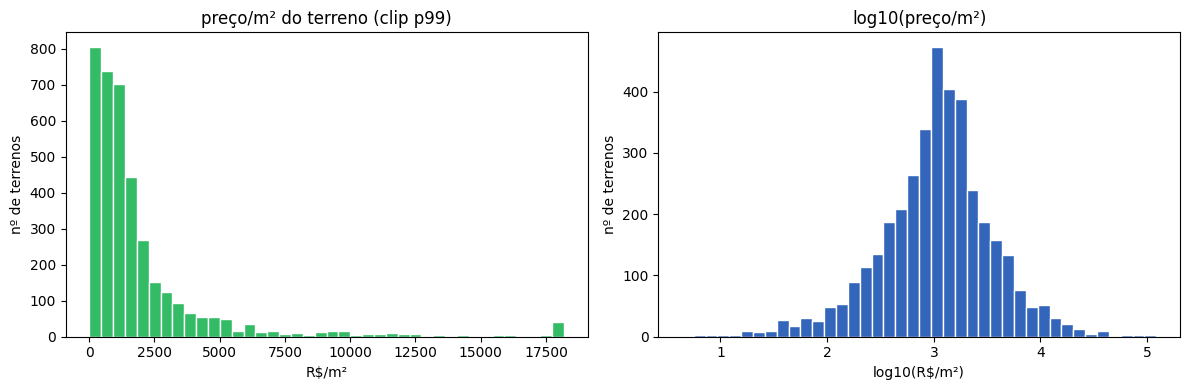

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(p.clip(upper=p.quantile(.99)), bins=40, color="#3b6", edgecolor="white")
ax[0].set_title("preço/m² do terreno (clip p99)"); ax[0].set_xlabel("R$/m²")
ax[1].hist(np.log10(p), bins=40, color="#36b", edgecolor="white")
ax[1].set_title("log10(preço/m²)"); ax[1].set_xlabel("log10(R$/m²)")
for a in ax:
    a.set_ylabel("nº de terrenos")
plt.tight_layout(); plt.show()

## 5. Conclusões e próximos passos

**Fatia vertical de dados fecha?** Sim. Para 2023/2024/2025 conseguimos, de ponta a ponta:
download → layout do ITBI → normalização do SQL → **teste do join** (com a lacuna do
`lote_cidadao` exposta) → **isolamento de terrenos** → **alvo preço/m²** com ordens de
grandeza coerentes para SP (mediana ~R$900–1.000/m²).

**Próximos passos:**
1. **(B) Cadastro tabular TPCL ano-alinhado** para a fase do modelo (junta o cadastro do
   *ano da transação*, evitando o viés de snapshot atual quando entrarem 2019–2022).
2. **Geometria** do `lote_cidadao` e **zoneamento** (camadas GeoSampa) só para *features*
   geoespaciais (Camada 5), cientes da cobertura parcial.
3. ✅ *Concluído:* os helpers maduros (`baixar_itbi`, `norm_sql10`, `ler_ano`, join) já
   foram promovidos para `src/loteia/data/` — este notebook agora os importa de lá.
4. Tratamento de outliers e definição final do alvo (incluindo natureza/proporção).